# Per-pixel phase anchoring over Chile (RTSIF, 2001–2020)

Land-surface-phenology extraction assumes a single growing-season bump **centered**
inside the day-of-year window [1, 365]. The failure mode is not "hemisphere" but the
**phase of each pixel's season relative to the 1-Jan cut**: an austral-summer season
(peak in January) *wraps* the year boundary, the pooled climatology becomes a U-shape,
and SOS/EOS/LOS come out wrong.

This notebook shows the per-pixel fix — `season_phase` + `PhenoLSP(hemisphere="auto")` —
on a reconstructed-TROPOMI-SIF (RTSIF; Chen et al., 2022) cube over all of continental
Chile (188×771 @ 0.05°, 8-day, 2001–2020).

> The SIF cube (`examples/data/SIF_Chile/`, ~0.5 GB) is **not** shipped with the package
> (it is git-ignored). The grid is coarsened 3× below purely for runtime; drop the
> `.coarsen(...)` line for full resolution.

In [1]:
import re, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import rioxarray  # noqa: F401  (registers the .rio accessor / open_rasterio)
import matplotlib.pyplot as plt

import phenosensing as ps

warnings.filterwarnings("ignore")

DATA = Path("data/SIF_Chile")
dates = pd.to_datetime(sorted(
    re.search(r"(\d{4}-\d{2}-\d{2})", f).group(1) for f in glob.glob(str(DATA / "RTSIF_*.tif"))
))
da = (
    rioxarray.open_rasterio(DATA / "SIF_Chile_all.tif")
    .rename({"band": "time"})
    .assign_coords(time=dates.values)
)
da = da.where(da > -1e30)  # mask the -3.4e38 nodata -> NaN
da = da.assign_coords(
    doy=("time", da.time.dt.dayofyear.values),
    year=("time", da.time.dt.year.values),
)
da = da.coarsen(x=3, y=3, boundary="trim").mean()  # 0.15 deg, for runtime only
dict(da.sizes)

{'time': 920, 'y': 257, 'x': 62}

## 1. Detect each pixel's seasonal phase

`season_phase` fits the first annual Fourier harmonic per pixel and returns the peak DOY,
the **anchor** (dormancy DOY = `peak + 182.5`, the start of the phenological year), a
seasonality **strength**, and an **aseasonal** flag (weak annual cycle, e.g. the Atacama).

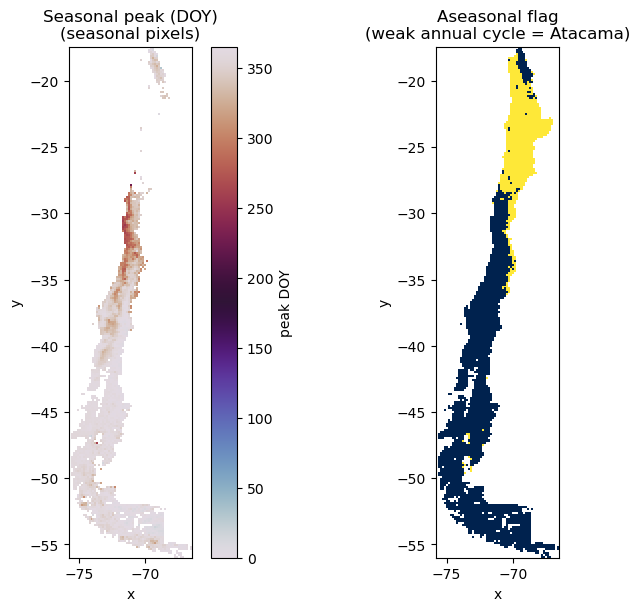

aseasonal fraction of LAND pixels (the arid north): 0.26


In [2]:
sp = ps.season_phase(da).compute()

land = np.isfinite(sp["strength"])
fig, ax = plt.subplots(1, 2, figsize=(9, 6), constrained_layout=True)
sp["peak_doy"].where(sp["aseasonal"] < 0.5).plot(
    ax=ax[0], cmap="twilight", vmin=0, vmax=365, cbar_kwargs={"label": "peak DOY"}
)
ax[0].set_title("Seasonal peak (DOY)\n(seasonal pixels)")
sp["aseasonal"].where(land).plot(ax=ax[1], cmap="cividis", add_colorbar=False)
ax[1].set_title("Aseasonal flag\n(weak annual cycle = Atacama)")
for a in ax:
    a.set_aspect("equal")
plt.show()

asea = float((sp["aseasonal"].where(land) > 0.5).sum() / land.sum())
print(f"aseasonal fraction of LAND pixels (the arid north): {asea:.2f}")

## 2. The fix: center each pixel before extracting metrics

Under `hemisphere="north"` (no rotation) the austral-summer pixels that dominate vegetated
Chile wrap the year boundary, so the extractor sees a season spanning almost the whole year
(LOS ≈ 365 d, SOS/EOS pinned to the window edges). `hemisphere="auto"` rotates each pixel
into a centered phenological-year frame, recovers a plausible season length, and maps
SOS/POS/EOS back to calendar DOY.

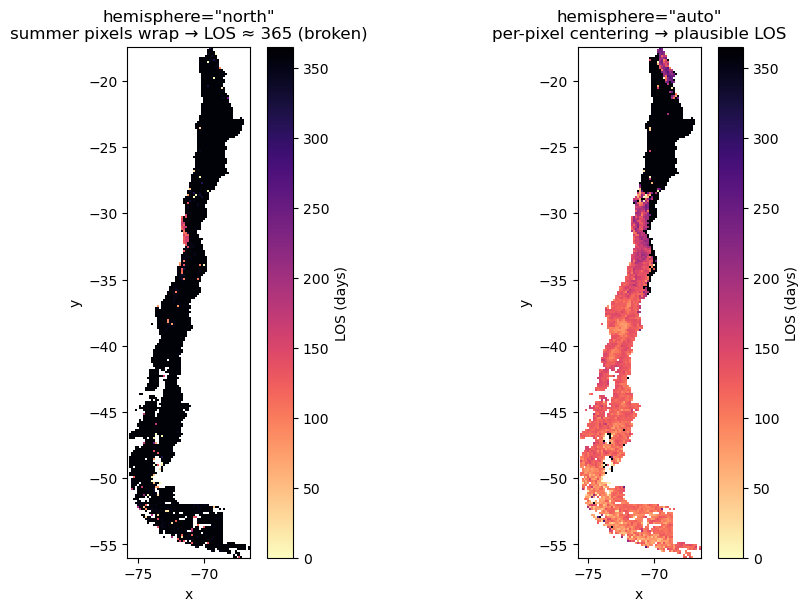

north : implausible-LOS fraction of seasonal pixels = 0.96
south : implausible-LOS fraction of seasonal pixels = 0.01
auto  : implausible-LOS fraction of seasonal pixels = 0.00


In [3]:
shape = da.pheno.PhenoShape(interpolType="linear", rollWindow=5, nGS=46)
los = {
    h: shape.pheno.PhenoLSP(hemisphere=h, extraction="trs").los.compute()
    for h in ("north", "auto", "south")
}

fig, ax = plt.subplots(1, 2, figsize=(9, 6), constrained_layout=True)
los["north"].plot(ax=ax[0], vmin=0, vmax=365, cmap="magma_r", cbar_kwargs={"label": "LOS (days)"})
ax[0].set_title('hemisphere="north"\nsummer pixels wrap → LOS ≈ 365 (broken)')
los["auto"].plot(ax=ax[1], vmin=0, vmax=365, cmap="magma_r", cbar_kwargs={"label": "LOS (days)"})
ax[1].set_title('hemisphere="auto"\nper-pixel centering → plausible LOS')
for a in ax:
    a.set_aspect("equal")
plt.show()

# fraction of seasonal land pixels with an implausible (≈ year-long) season
seasonal = np.isfinite(sp["strength"]) & (sp["aseasonal"] < 0.5)
n = float(seasonal.sum())
for h in ("north", "south", "auto"):
    bad = float(((los[h] > 300) & seasonal).sum()) / n
    print(f"{h:6s}: implausible-LOS fraction of seasonal pixels = {bad:.2f}")

## 3. What this shows (and the honest caveats)

- **`north` is broken across vegetated Chile**: the dominant austral-summer phenology wraps
  the 1-Jan cut, so LOS saturates near 365 days. **`auto` fixes it per pixel**, and flags the
  Atacama as aseasonal (left unrotated).
- In *this* RTSIF product the vegetated signal is almost entirely austral-summer, so
  `auto ≈ south` here — a single global flag would also work. The advantage of *per-pixel*
  `auto` appears when a scene **mixes regimes** (e.g. winter-green shrubland alongside summer
  crops, or a cross-equator mosaic): `"south"` would then break the winter-peaking pixels
  while `"north"` breaks the summer ones — only per-pixel anchoring handles both (see the
  synthetic case in `tests/test_phase.py` and the regime table in `docs/methods.md`). `auto`
  also removes the need to *know* the regime a priori.
- **Why not validate with bootstrap `uncertainty`?** A mis-centered extraction is usually
  *stably* wrong (it pins SOS/EOS to the window edge on every replicate), so its bootstrap
  spread is small — uncertainty measures precision, not accuracy. The **physical plausibility
  of LOS** above is the right discriminator.